In [202]:
import os 
import random
import nnsight
import importlib
import pandas as pd
from utils.utils import send_openrouter_request

import torch
import torch.nn.functional as F 

from utils.utils import flag_message_types
from utils.style import stylize_sample_simple

excerpts = pd.read_csv('../data/eval/041926_excerpts.csv')

In [ ]:
from transformers import AutoConfig
# id = 'qwen/qwen3-30b-a3b-instruct-2507'
# id = 'Qwen/Qwen3.6-35B-A3B'
# id = 'zai-org/GLM-5.1'
# id = 'moonshotai/Kimi-K2.6'

# Interp.

In [6]:
#### representations
import torch.nn.functional as F
from nnsight import LanguageModel
from transformers import AutoTokenizer
import utils.style as style
# id = 'qwen/qwen3-30b-a3b-instruct-2507'
id = 'Qwen/Qwen3.6-35B-A3B'
model = LanguageModel(id, device_map = 'auto', remote = 'true')
tokenizer = AutoTokenizer.from_pretrained(id)

AttributeError: 'Qwen3_5MoeConfig' object has no attribute 'vocab_size'

In [106]:
from transformers import AutoConfig
id = 'qwen/qwen3-30b-a3b-instruct-2507'
model = LanguageModel(id, device_map = 'auto', remote = 'true')

In [110]:
from nnsight.modeling.language import LanguageModel

model = LanguageModel("allenai/Olmo-3-1025-7B", remote = 'true')

config.json: 0.00B [00:00, ?B/s]

`rope_parameters`'s beta_fast field must be a float, got 32
`rope_parameters`'s beta_slow field must be a float, got 1


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/207 [00:00<?, ?B/s]

In [111]:
from pathlib import Path

text = Path("../data/transcripts/2_two_michaels.txt").read_text(encoding="utf-8")
print(text)

with model.trace(text, remote = True):
    # Access attention output
    attn_output = model.model.layers[24].self_attn.output.save()

    

Michael: Hey there Mike, it's nice to see you at the dog park, how are you today? 
Mike: Oh hey there Michael, nice to see you too, your dog is looking really cute today.
Mike: What's his name again, blueberry?  
Mike: My brain thinks that because every time I see you guys, I'm reminded of berry picking. 
Michael: Yup, that's spot on Mike, funny way to remember that. 
Michael. And what's your dog's name again? 
Michael: So cute, is she a german shepherd mix?  
Mike: Ah nah, we're not sure about frosting, we got her from Paws Humane, my wife, Kristi, loved that dog at first sight.
Mike: The workers there think she's even got some chihuahua in her, who knows…
Mike: All I know is that she loves when I go out golfing, lots of balls to chase ya know.
Michael: yes, blueberry loves that too when I'm playing tennis. 
Michael: But his favorite place just might be daycare, he really loves the Fresh Market next to it, especially on Fridays when salmon goes on sale (haha)
Mike: Frosting is exactly

⬇ Downloading:   0%|          | 0.00/4.32M [00:00<?]

In [159]:
# extract full attention matrix for head 19 — slicing is done in the plot cell
HEAD = 18
attn_full = attn_output[1].squeeze(0)[HEAD].float().cpu().numpy()  # [305, 305]

tokenizer = AutoTokenizer.from_pretrained(id)
toks = tokenizer.encode(text)
token_labels = [tokenizer.decode([t]).replace('\n', '↵') for t in toks]

print(f"seq len: {len(toks)}, attn shape: {attn_full.shape}")

seq len: 305, attn shape: (305, 305)


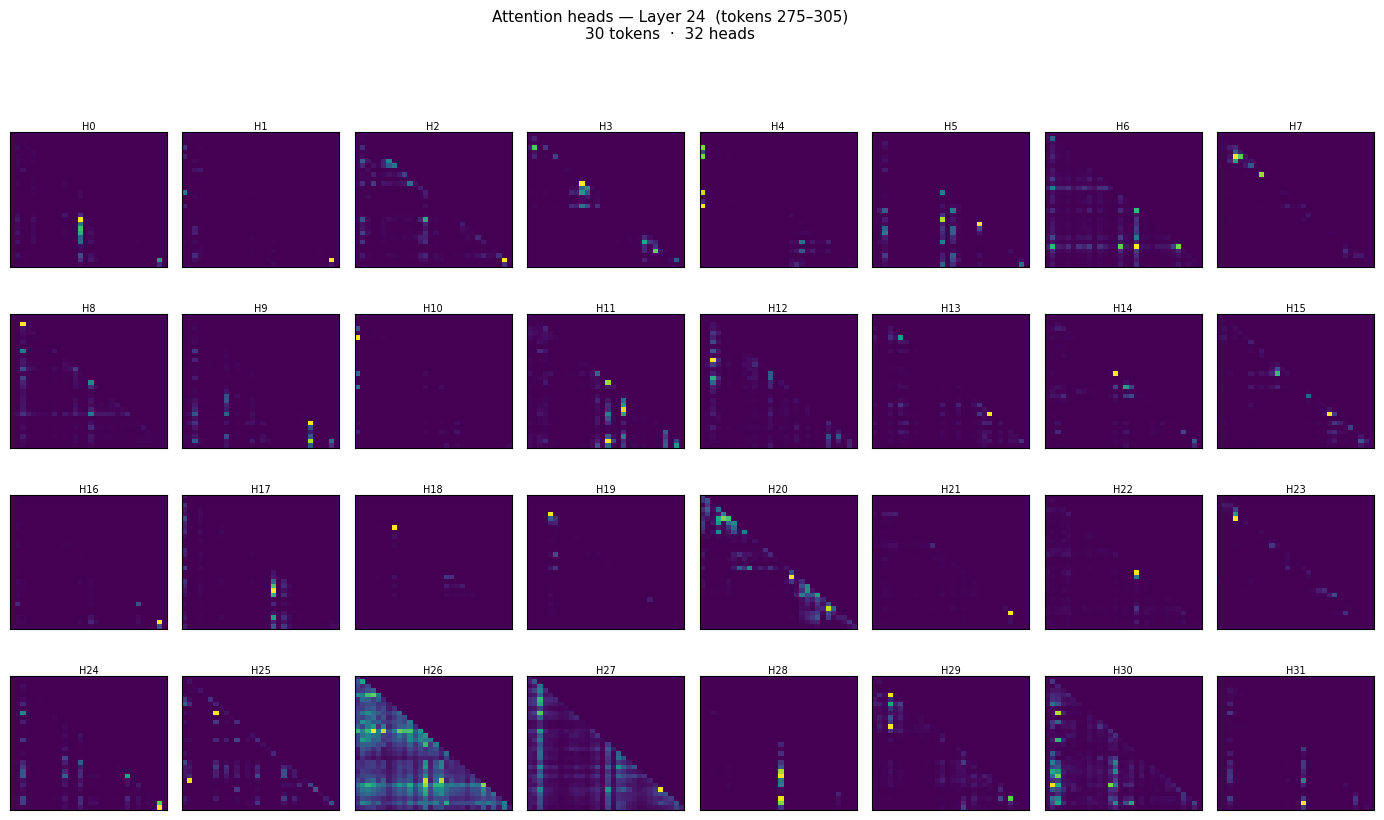

In [178]:
import matplotlib.pyplot as plt
import numpy as np

# ── token window ─────────────────────────────────────────────────────────
start_tok = 275
end_tok   = len(token_labels)  # or e.g. 100 to zoom in
# ─────────────────────────────────────────────────────────────────────────

# pull all heads out of the nnsight proxy into numpy first
all_heads = attn_output[1].squeeze(0).float().cpu().numpy()  # [n_heads, seq, seq]
n_heads   = all_heads.shape[0]

ncols = 8
nrows = int(np.ceil(n_heads / ncols))

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 2.2, nrows * 2.2),
                         gridspec_kw=dict(hspace=0.35, wspace=0.1))
axes_flat = axes.flatten()

for h in range(n_heads):
    ax     = axes_flat[h]
    sliced = all_heads[h, start_tok:end_tok, start_tok:end_tok]
    ax.imshow(sliced, cmap='viridis', aspect='auto', interpolation='nearest')
    ax.set_title(f'H{h}', fontsize=7, pad=2)
    ax.set_xticks([])
    ax.set_yticks([])

for h in range(n_heads, len(axes_flat)):
    axes_flat[h].set_visible(False)

fig.suptitle(
    f'Attention heads — Layer 24  (tokens {start_tok}–{end_tok})\n'
    f'{end_tok - start_tok} tokens  ·  {n_heads} heads',
    fontsize=11, y=1.02
)
plt.show()

In [194]:
text = Path("../data/transcripts/6_same_michaels.txt").read_text(encoding="utf-8")
print(text)

Michael: HEY THERE MICHAEL, IT'S NICE TO SEE YOU AT THE DOG PARK. HOW ARE YOU TODAY?
Michael: oh hey there michael, nice to see you too. your dog is looking really cute today.
Michael: what's his name again, blueberry?
Michael: my brain thinks that because every time i see you guys, i'm reminded of berry picking.
Michael: YUP, THAT'S SPOT ON MIKE. FUNNY WAY TO REMEMBER THAT.
Michael: AND WHAT'S YOUR DOG'S NAME AGAIN?
Michael: SO CUTE. IS SHE A GERMAN SHEPHERD MIX?
Michael: ah nah, we're not sure about frosting. we got her from paws humane, and my wife, kristi, loved that dog at first sight.
Michael: the workers there think she's even got some chihuahua in her, who knows...
Michael: all i know is that she loves when i go out golfing. lots of balls to chase, ya know.
Michael: YES, BLUEBERRY LOVES THAT TOO WHEN I'M PLAYING TENNIS.
Michael: oh wow, y'all like to play tennis, so does my sweet little darling frosting.
Michael: BUT HIS FAVORITE PLACE JUST MIGHT BE DAYCARE. HE REALLY LOVES THE

Mean A:     8.555  (std 2.489)
Mean B:     2.003  (std 2.876)
Gap:        6.552
Boundary:   5.279
Cohen's d:  2.436


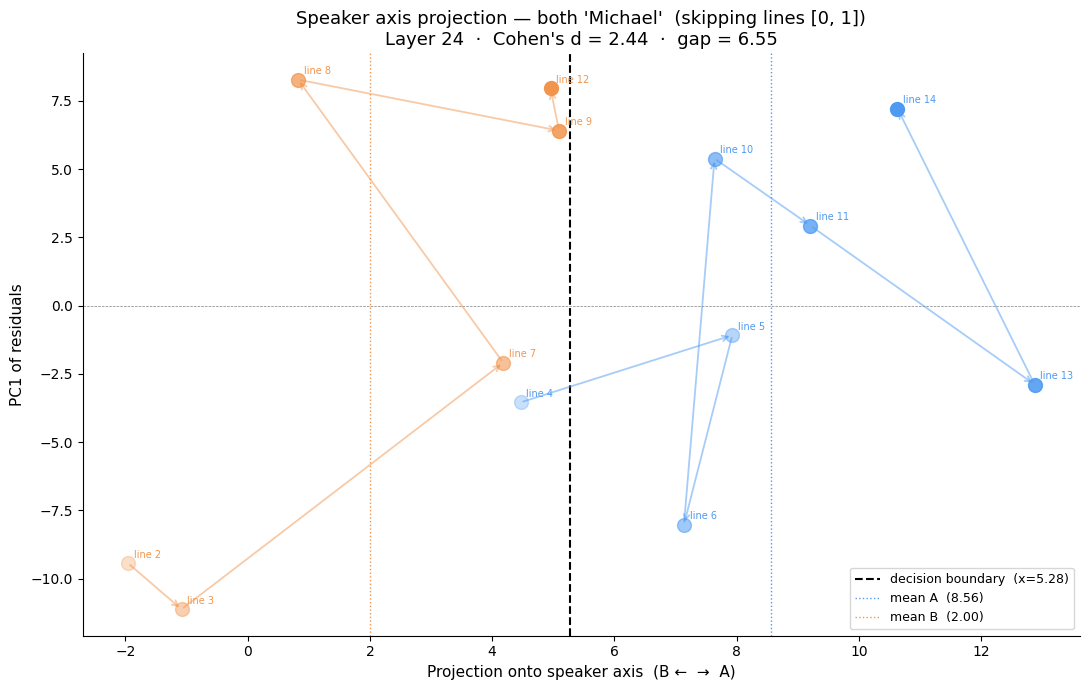

In [198]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── settings ────────────────────────────────────────────────────────────────
SKIP_LINES = {0, 1}   # remove these dialogue lines (0-indexed) from the analysis
# ────────────────────────────────────────────────────────────────────────────

# filter name_hits, vecs, speakers by SKIP_LINES
keep = [i for i, (_, _, line_i) in enumerate(name_hits) if line_i not in SKIP_LINES]
vecs_f     = vecs[keep]
speakers_f = [speakers[i] for i in keep]
hits_f     = [name_hits[i] for i in keep]

spk_a_idx = [i for i, s in enumerate(speakers_f) if s == 'Speaker A']
spk_b_idx = [i for i, s in enumerate(speakers_f) if s == 'Speaker B']
spk_a_vecs = vecs_f[spk_a_idx]
spk_b_vecs = vecs_f[spk_b_idx]

# speaker axis (unit vector pointing from B → A)
speaker_axis = spk_a_vecs.mean(0) - spk_b_vecs.mean(0)
speaker_axis = speaker_axis / np.linalg.norm(speaker_axis)

proj_x = vecs_f @ speaker_axis

mean_a   = proj_x[spk_a_idx].mean()
mean_b   = proj_x[spk_b_idx].mean()
std_a    = proj_x[spk_a_idx].std()
std_b    = proj_x[spk_b_idx].std()
boundary = (mean_a + mean_b) / 2
cohens_d = (mean_a - mean_b) / np.sqrt((std_a**2 + std_b**2) / 2)

print(f"Mean A:     {mean_a:.3f}  (std {std_a:.3f})")
print(f"Mean B:     {mean_b:.3f}  (std {std_b:.3f})")
print(f"Gap:        {mean_a - mean_b:.3f}")
print(f"Boundary:   {boundary:.3f}")
print(f"Cohen's d:  {cohens_d:.3f}")

# second axis: PC1 of residuals
residuals = vecs_f - np.outer(proj_x, speaker_axis)
proj_y    = PCA(n_components=1).fit_transform(residuals).squeeze()

# ── plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

for spk, color in COLORS.items():
    idx = spk_a_idx if spk == 'Speaker A' else spk_b_idx
    xs, ys = proj_x[idx], proj_y[idx]

    for j in range(len(idx) - 1):
        ax.annotate('', xy=(xs[j+1], ys[j+1]), xytext=(xs[j], ys[j]),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.3, alpha=0.5))

    alphas = np.linspace(0.3, 1.0, len(idx))
    for j, (x, y, a) in enumerate(zip(xs, ys, alphas)):
        ax.scatter(x, y, color=color, alpha=a, s=100, zorder=3)
        ax.annotate(f'line {hits_f[idx[j]][2]}', (x, y),
                    fontsize=7, color=color, xytext=(4, 4),
                    textcoords='offset points')

ax.axvline(boundary, color='black', lw=1.5, ls='--',
           label=f'decision boundary  (x={boundary:.2f})')
ax.axvline(mean_a, color=COLORS['Speaker A'], lw=1, ls=':',
           label=f'mean A  ({mean_a:.2f})')
ax.axvline(mean_b, color=COLORS['Speaker B'], lw=1, ls=':',
           label=f'mean B  ({mean_b:.2f})')
ax.axhline(0, color='grey', lw=0.5, ls='--')

ax.set_xlabel("Projection onto speaker axis  (B ←  →  A)", fontsize=11)
ax.set_ylabel("PC1 of residuals", fontsize=11)
ax.set_title(
    f"Speaker axis projection — both 'Michael'  (skipping lines {sorted(SKIP_LINES)})\n"
    f"Layer {LAYER}  ·  Cohen's d = {cohens_d:.2f}  ·  gap = {mean_a - mean_b:.2f}",
    fontsize=13
)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


In [176]:
# run the paired strong-vs-weak comparison over excerpts with at least 2 speakers
results_df = style_module.run_style_strength_experiment(
    excerpts,
    tokenizer,
    model,
    n_samples=35,
    min_num_speakers=2,
)

NameError: name 'style_module' is not defined

In [172]:
# Diagnostic: compare individual assignment norms against weak
for row_ix in range(min(35, len(candidate_excerpts))):
    row_df = candidate_excerpts.iloc[row_ix:row_ix+1].reset_index(drop=True)
    stylized_sample = style_module.stylize_sample_simple(row_df)
    pooled = style_module.get_probe_speaker_vectors(
        stylized_sample, tokenizer, model,
    )
    
    speaker_a, speaker_b = pooled['speaker_pair']
    
    d_weak = pooled['baseline'][speaker_b] - pooled['baseline'][speaker_a]
    d_1 = pooled['style'][speaker_b] - pooled['style'][speaker_a]
    d_2 = pooled['style_reverse'][speaker_b] - pooled['style_reverse'][speaker_a]
    d_strong = (d_1 + d_2) / 2
    
    print(f"Dialogue {row_ix}: "
          f"||D1||={np.linalg.norm(d_1):.4f}  "
          f"||D2||={np.linalg.norm(d_2):.4f}  "
          f"||D_strong||={np.linalg.norm(d_strong):.4f}  "
          f"||D_weak||={np.linalg.norm(d_weak):.4f}")

NameError: name 'candidate_excerpts' is not defined

In [ ]:
norm_strongs = []
norm_weaks = []

for each dialogue:
    D1 = h_green_assign1 - h_pink_assign1
    D2 = h_green_assign2 - h_pink_assign2
    D_strong = (D1 + D2) / 2
    D_weak = h_green_weak - h_pink_weak
    
    norm_strongs.append(np.linalg.norm(D_strong))
    norm_weaks.append(np.linalg.norm(D_weak))

,source_index,speaker_a,speaker_b,norm_strong,norm_weak,strong_minus_weak
0,0,1.Pink,1.Green,4.317180,4.449694,-0.132514
1,1,1.Pink,1.Blue,4.418630,4.600684,-0.182054
2,2,1.Pink,1.Green,4.312086,4.538441,-0.226355
3,3,1.Blue,1.Pink,4.413880,4.537596,-0.123716
4,4,1.Pink,1.Blue,4.601618,4.839272,-0.237655
5,5,1.Blue,1.Pink,4.446874,4.529378,-0.082504
6,6,1.Green,1.Blue,4.305222,4.488345,-0.183123
7,7,1.Green,1.Pink,4.522646,4.658487,-0.135841
8,8,1.Blue,1.Pink,4.402734,4.640802,-0.238068
9,9,10.Pink,10.Orange,4.499363,4.350347,0.149017


In [240]:
pprint.pprint(candidate_excerpts.iloc[31]['baseline_text'])

('13.Blue: "Yeah"\n'
 '13.Yellow: "Mhm"\n'
 '13.Blue: "Uh steel wool"\n'
 '13.Yellow: "Compass"\n'
 '13.Yellow: "Okay"\n'
 '13.Yellow: "And uh"\n'
 '13.Yellow: "Uh"\n'
 '13.Blue: "Thirteen already and the fourteen"\n'
 '13.Yellow: "What is the ball of steel going to do"\n'
 '13.Yellow: "Steel wool"\n'
 '13.Blue: "Steel wool"\n'
 '13.Yellow: "What will it do"\n'
 '13.Blue: "Steel wool is like uh like uh like uh steel heat uh [unclear]"\n'
 '13.Yellow: "I know"\n'
 '13.Yellow: "Yeah because create a spark"\n'
 '13.Yellow: "We have a lighter thats kind of "\n'
 '13.Yellow: "Depending on survivors but"\n'
 '13.Blue: "Yeah"\n'
 '13.Yellow: "Rope may help traverse if we plan to be coming out a little '
 'more"\n'
 '13.Blue: "Yeah"\n'
 '13.Yellow: "So I I would do steel wool as fourteen"\n'
 '13.Blue: "[unclear]"\n'
 '13.Yellow: "Ski poles or third or last"\n'
 '13.Yellow: "Ski poles you might want to build a hi hike"\n'
 '13.Yellow: "Ill do that as last"\n'
 '13.Yellow: "So I would I would d

In [ ]:
from scipy import stats

t_stat, p_val = stats.ttest_rel(norm_strongs, norm_weaks, alternative='greater')
diff = np.array(norm_strongs) - np.array(norm_weaks)
cohens_d = np.mean(diff) / np.std(diff)

print(f"t={t_stat:.3f}, p={p_val:.4f}, d={cohens_d:.3f}")
print(f"mean strong: {np.mean(norm_strongs):.4f}")
print(f"mean weak: {np.mean(norm_weaks):.4f}")

n=35
t=-3.793, p=0.9997, d=-0.651
mean strong: 4.4205
mean weak: 4.5064


Text(0.5, 0, 'dialogue')

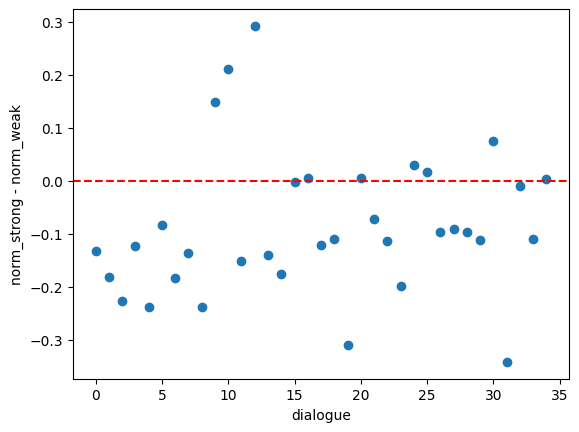

In [ ]:
plt.scatter(range(len(diff)), diff)
plt.axhline(0, color='red', linestyle='--')
plt.ylabel('norm_strong - norm_weak')
plt.xlabel('dialogue')

⬇ Downloading:   0%|          | 0.00/2.62M [00:00<?]

hidden states shape: (409, 4096)
Speaker A tokens: 203  |  Speaker B tokens: 158
Mean A: -3.712  Mean B: -3.794  Gap: 0.082  Cohen's d: 0.361


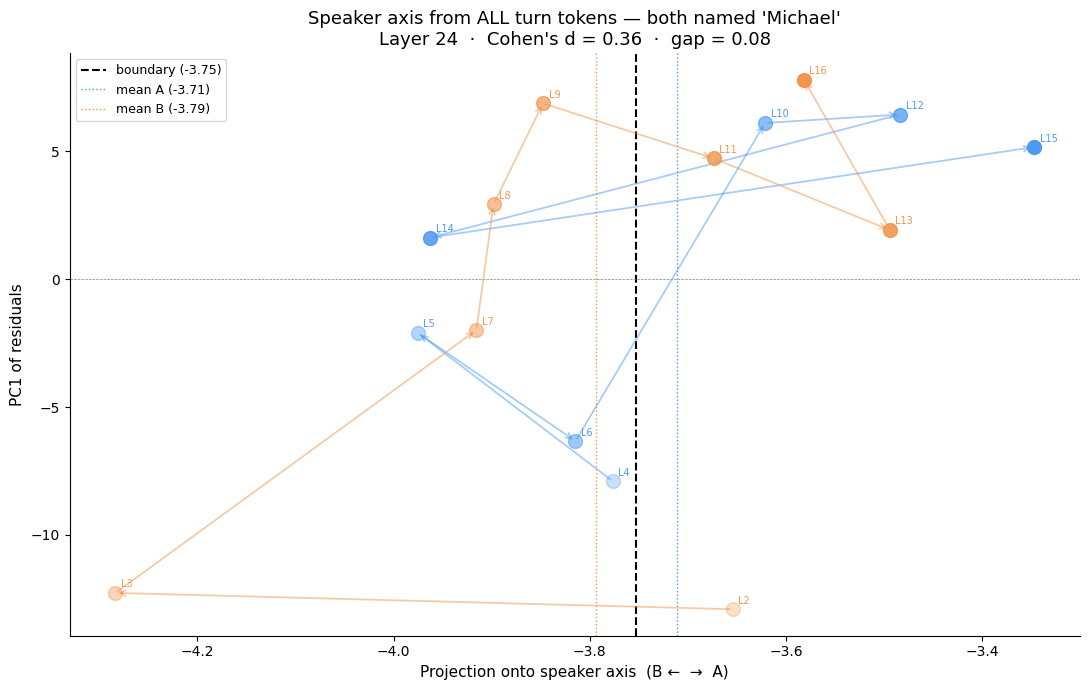

In [200]:
from pathlib import Path
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── settings ────────────────────────────────────────────────────────────────
LAYER      = 24
SKIP_LINES = {0, 1}
COLORS     = {'Speaker A': '#4e9af1', 'Speaker B': '#f1954e'}
# ────────────────────────────────────────────────────────────────────────────

same_text  = Path('../data/transcripts/6_same_michaels.txt').read_text()
same_lines = same_text.splitlines()

def speaker_from_case(line):
    content = line.split('Michael: ', 1)[-1]
    n_upper = sum(c.isupper() for c in content if c.isalpha())
    n_lower = sum(c.islower() for c in content if c.isalpha())
    return 'Speaker A' if n_upper > n_lower else 'Speaker B'

line_speaker = [speaker_from_case(ln) for ln in same_lines]

# model trace
with model.trace(same_text, remote=True):
    hidden_same = model.model.layers[LAYER].output[0].save()

hidden_np = hidden_same.squeeze(0).float().cpu().numpy()
print(f"hidden states shape: {hidden_np.shape}")

# build char → line index lookup
enc     = tokenizer(same_text, return_offsets_mapping=True)
offsets = enc['offset_mapping']

char_to_line = {}
char = 0
for line_i, line in enumerate(same_lines):
    for c in range(len(line) + 1):
        char_to_line[char + c] = line_i
    char += len(line) + 1

# assign every token to a line + speaker
tok_line    = [char_to_line.get(s, None) for s, e in offsets]
tok_speaker = [line_speaker[l] if l is not None else None for l in tok_line]

# collect ALL token hidden states per speaker (excluding SKIP_LINES)
spk_a_all = np.vstack([hidden_np[i] for i, (l, s) in enumerate(zip(tok_line, tok_speaker))
                        if s == 'Speaker A' and l not in SKIP_LINES])
spk_b_all = np.vstack([hidden_np[i] for i, (l, s) in enumerate(zip(tok_line, tok_speaker))
                        if s == 'Speaker B' and l not in SKIP_LINES])

print(f"Speaker A tokens: {len(spk_a_all)}  |  Speaker B tokens: {len(spk_b_all)}")

# speaker axis from ALL turn tokens
speaker_axis = spk_a_all.mean(0) - spk_b_all.mean(0)
speaker_axis = speaker_axis / np.linalg.norm(speaker_axis)

# ── project speaker-prefix "Michael" tokens for the plot ────────────────────
name_hits = []
for tok_i, (char_s, char_e) in enumerate(offsets):
    if same_text[char_s:char_e].strip() != 'Michael':
        continue
    line_i = char_to_line.get(char_s)
    if line_i is None or line_i in SKIP_LINES:
        continue
    line_char_start = sum(len(l) + 1 for l in same_lines[:line_i])
    if same_text[line_char_start:char_s].strip() == '':
        name_hits.append((tok_i, line_speaker[line_i], line_i))

positions = [t for t, _, _ in name_hits]
speakers  = [s for _, s, _ in name_hits]
vecs      = hidden_np[positions]

proj_x = vecs @ speaker_axis

spk_a_idx = [i for i, s in enumerate(speakers) if s == 'Speaker A']
spk_b_idx = [i for i, s in enumerate(speakers) if s == 'Speaker B']
mean_a    = proj_x[spk_a_idx].mean()
mean_b    = proj_x[spk_b_idx].mean()
std_a     = proj_x[spk_a_idx].std()
std_b     = proj_x[spk_b_idx].std()
boundary  = (mean_a + mean_b) / 2
cohens_d  = (mean_a - mean_b) / np.sqrt((std_a**2 + std_b**2) / 2)

residuals = vecs - np.outer(proj_x, speaker_axis)
proj_y    = PCA(n_components=1).fit_transform(residuals).squeeze()

print(f"Mean A: {mean_a:.3f}  Mean B: {mean_b:.3f}  Gap: {mean_a-mean_b:.3f}  Cohen's d: {cohens_d:.3f}")

# ── plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
for spk, color in COLORS.items():
    idx = spk_a_idx if spk == 'Speaker A' else spk_b_idx
    xs, ys = proj_x[idx], proj_y[idx]
    for j in range(len(idx) - 1):
        ax.annotate('', xy=(xs[j+1], ys[j+1]), xytext=(xs[j], ys[j]),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.3, alpha=0.5))
    alphas = np.linspace(0.3, 1.0, len(idx))
    for j, (x, y, a) in enumerate(zip(xs, ys, alphas)):
        ax.scatter(x, y, color=color, alpha=a, s=100, zorder=3)
        ax.annotate(f'L{name_hits[idx[j]][2]}', (x, y),
                    fontsize=7, color=color, xytext=(4, 4), textcoords='offset points')

ax.axvline(boundary, color='black', lw=1.5, ls='--', label=f'boundary ({boundary:.2f})')
ax.axvline(mean_a, color=COLORS['Speaker A'], lw=1, ls=':', label=f'mean A ({mean_a:.2f})')
ax.axvline(mean_b, color=COLORS['Speaker B'], lw=1, ls=':', label=f'mean B ({mean_b:.2f})')
ax.axhline(0, color='grey', lw=0.5, ls='--')
ax.set_xlabel('Projection onto speaker axis  (B ←  →  A)', fontsize=11)
ax.set_ylabel('PC1 of residuals', fontsize=11)
ax.set_title(
    f"Speaker axis from ALL turn tokens — both named 'Michael'\n"
    f"Layer {LAYER}  ·  Cohen's d = {cohens_d:.2f}  ·  gap = {mean_a - mean_b:.2f}",
    fontsize=13)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
